In [2]:
pip install pandas openpyxl


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from pathlib import Path

In [4]:
import pandas as pd

FILE = "birthsandinfantmortalitybyethnicity2007to20192.xlsx"

# read the raw sheet with no header assumption, so we can see exactly
# how the rows are laid out before deciding where the real header is
raw = pd.read_excel(FILE, sheet_name="Table 13", header=None)

print("Shape:", raw.shape)
print("\nFirst 8 rows, all columns:\n")
for i in range(8):
    print(f"Row {i}:", list(raw.iloc[i]))

Shape: (161, 24)

First 8 rows, all columns:

Row 0: ['Contents', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan]
Row 1: ['Table 13: Infant deaths in England: ethnicity of infant and Index of Multiple Deprivation (IMD) deciles, numbers and rates, 2007 to 2019', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan]
Row 2: ['England', nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan]
Row 3: [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, np.float64(nan), nan, nan]
Row 4: ['Year', 'Index of Multiple Deprivation4,5,6,7', nan, 'Infant deaths', nan, nan, nan, nan, nan, nan, 'Infant Mortality Rate2,3', np.float64(nan), nan, nan, nan, nan, nan, nan, nan, nan, nan, 

In [5]:
import pandas as pd

FILE = "birthsandinfantmortalitybyethnicity2007to20192.xlsx"

raw = pd.read_excel(FILE, sheet_name="Table 13", header=None)

data = raw.iloc[6:].reset_index(drop=True)

# build clean column names by hand, based on rows 4-5 structure
ethnic_groups = ["All", "Asian", "Black", "Mixed_or_multiple", "Any_Other_ethnic_group", "White", "Not_Stated"]

columns = (
    ["year", "imd_decile"]
    + [f"infant_deaths_{g}" for g in ethnic_groups]
    + ["unlinked_deaths"]
)

for g in ethnic_groups:
    columns += [f"infant_mortality_rate_{g}", f"infant_mortality_rate_{g}_flag"]

data.columns = columns

data = data.dropna(how="all")

print(data.shape)
data.head(10)

(153, 24)


,year,imd_decile,infant_deaths_All,infant_deaths_Asian,infant_deaths_Black,infant_deaths_Mixed_or_multiple,infant_deaths_Any_Other_ethnic_group,infant_deaths_White,infant_deaths_Not_Stated,unlinked_deaths,...,infant_mortality_rate_Black,infant_mortality_rate_Black_flag,infant_mortality_rate_Mixed_or_multiple,infant_mortality_rate_Mixed_or_multiple_flag,infant_mortality_rate_Any_Other_ethnic_group,infant_mortality_rate_Any_Other_ethnic_group_flag,infant_mortality_rate_White,infant_mortality_rate_White_flag,infant_mortality_rate_Not_Stated,infant_mortality_rate_Not_Stated_flag
0,2019,1,444,110,43,33,18,199,21,20,...,6.6,NaN,6.2,NaN,6,u,3.9,NaN,7.1,NaN
1,2019,2,333,73,44,14,15,163,13,11,...,6.4,NaN,2.5,u,6.2,u,3.6,NaN,7.2,u
2,2019,3,286,62,38,17,3,144,14,8,...,6.6,NaN,3.2,u,1.2,u,3.2,NaN,7.3,u
3,2019,4,254,43,22,26,4,145,8,6,...,6.1,NaN,5.7,NaN,2.2,u,3.3,NaN,5,u
4,2019,5,220,33,18,11,5,131,17,5,...,7,u,2.7,u,3.7,u,3,NaN,10.3,u
5,2019,6,196,31,9,9,5,127,12,3,...,4.9,u,2.4,u,4.2,u,2.9,NaN,7.6,u
6,2019,7,154,15,8,8,4,108,9,2,...,6.5,u,2.4,u,4.4,u,2.6,NaN,6.4,u
7,2019,8,140,14,6,11,1,100,8,0,...,6.2,u,3.4,u,NaN,u,2.4,NaN,5.2,u
8,2019,9,128,13,7,10,0,87,7,4,...,9,u,3.3,u,NaN,u,2.2,NaN,6.3,u
9,2019,10,103,7,1,4,0,83,4,4,...,NaN,u,1.4,u,NaN,u,2.3,NaN,3.7,u


In [6]:
# reshape from wide to long: one row per year, imd_decile, ethnicity
records = []

for _, row in data.iterrows():
    for g in ethnic_groups:
        records.append({
            "year": row["year"],
            "imd_decile": row["imd_decile"],
            "ethnic_group": g,
            "infant_deaths": row[f"infant_deaths_{g}"],
            "infant_mortality_rate": row[f"infant_mortality_rate_{g}"],
            "rate_unreliable_flag": row[f"infant_mortality_rate_{g}_flag"] == "u",
        })

long_df = pd.DataFrame(records)

long_df = long_df[~long_df["ethnic_group"].isin(["All", "Not_Stated"])].reset_index(drop=True)

print(long_df.shape)
long_df.head(15)

(765, 6)


,year,imd_decile,ethnic_group,infant_deaths,infant_mortality_rate,rate_unreliable_flag
0,2019,1,Asian,110,8.0,False
1,2019,1,Black,43,6.6,False
2,2019,1,Mixed_or_multiple,33,6.2,False
3,2019,1,Any_Other_ethnic_group,18,6.0,True
4,2019,1,White,199,3.9,False
5,2019,2,Asian,73,5.9,False
6,2019,2,Black,44,6.4,False
7,2019,2,Mixed_or_multiple,14,2.5,True
8,2019,2,Any_Other_ethnic_group,15,6.2,True
9,2019,2,White,163,3.6,False


In [7]:
import os

os.makedirs("data/processed", exist_ok=True)
long_df.to_csv("data/processed/master_health.csv", index=False)
print("Saved:", long_df.shape)

Saved: (765, 6)


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style("whitegrid")

df = pd.read_csv("data/processed/master_health.csv")
print(df.shape)
df.head()


(765, 6)


,year,imd_decile,ethnic_group,infant_deaths,infant_mortality_rate,rate_unreliable_flag
0,2019,1,Asian,110,8.0,False
1,2019,1,Black,43,6.6,False
2,2019,1,Mixed_or_multiple,33,6.2,False
3,2019,1,Any_Other_ethnic_group,18,6.0,True
4,2019,1,White,199,3.9,False


In [50]:
mortality_by_ethnicity = (
    df.groupby("ethnic_group")["infant_mortality_rate"]
    .mean()
    .sort_values(ascending=False)
)
print(mortality_by_ethnicity)


ethnic_group
Black                     7.070085
Asian                     4.922308
Any_Other_ethnic_group    4.566667
Mixed_or_multiple         3.938281
White                     3.330769
Name: infant_mortality_rate, dtype: float64


imd_decile
1        5.992308
10       4.402083
2        5.218462
3        4.612308
4        4.770313
5        4.626984
6        4.368333
7        4.514516
8        4.398148
9        4.092308
Total    4.781538
Name: infant_mortality_rate, dtype: float64


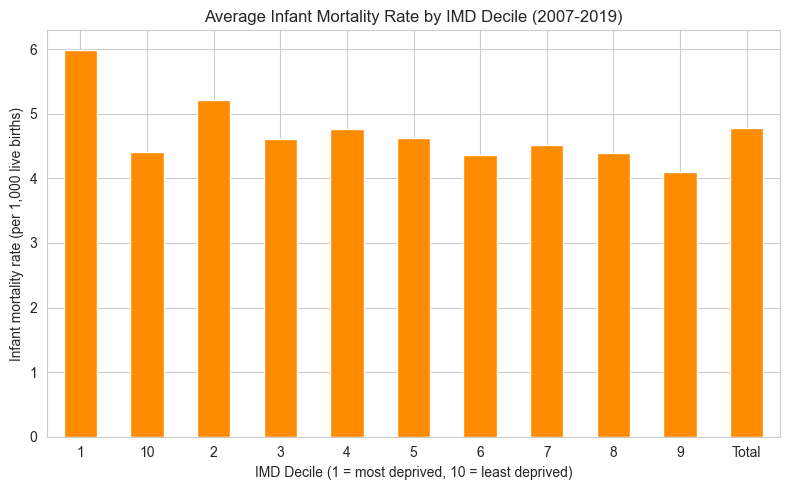

In [12]:
mortality_by_decile = (
    df.groupby("imd_decile")["infant_mortality_rate"]
    .mean()
)
print(mortality_by_decile)

fig, ax = plt.subplots(figsize=(8, 5))
mortality_by_decile.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Average Infant Mortality Rate by IMD Decile (2007-2019)")
ax.set_ylabel("Infant mortality rate (per 1,000 live births)")
ax.set_xlabel("IMD Decile (1 = most deprived, 10 = least deprived)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/figures/mortality_by_deprivation.png", dpi=150)
plt.show()

In [13]:

print(df["imd_decile"].unique())

['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' 'Total' nan]


In [14]:
# drop rows where imd_decile is missing or the summary "Total" row
df = df[df["imd_decile"].notna()]
df = df[df["imd_decile"] != "Total"].copy()

df["imd_decile"] = df["imd_decile"].astype(int)

print(df["imd_decile"].unique())
print(df.shape)

[ 1  2  3  4  5  6  7  8  9 10]
(650, 6)


imd_decile
1     5.992308
2     5.218462
3     4.612308
4     4.770313
5     4.626984
6     4.368333
7     4.514516
8     4.398148
9     4.092308
10    4.402083
Name: infant_mortality_rate, dtype: float64


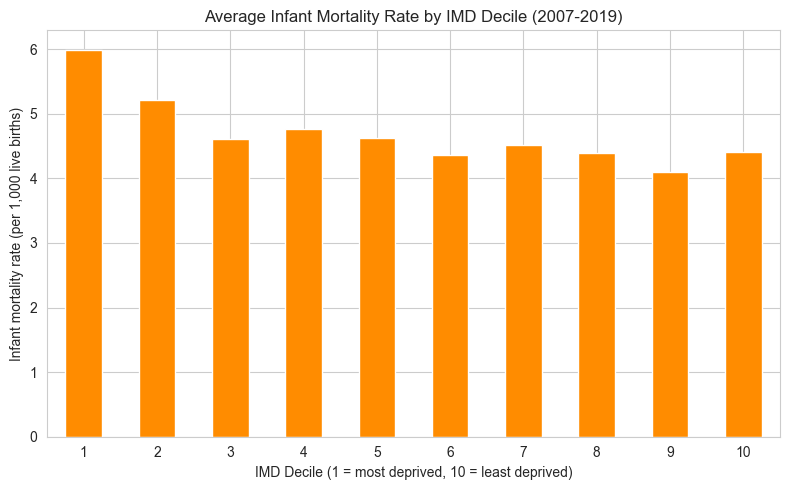

In [15]:
mortality_by_decile = (
    df.groupby("imd_decile")["infant_mortality_rate"]
    .mean()
    .sort_index()   # ensures 1,2,3...10 order, not alphabetical
)
print(mortality_by_decile)

fig, ax = plt.subplots(figsize=(8, 5))
mortality_by_decile.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Average Infant Mortality Rate by IMD Decile (2007-2019)")
ax.set_ylabel("Infant mortality rate (per 1,000 live births)")
ax.set_xlabel("IMD Decile (1 = most deprived, 10 = least deprived)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/figures/mortality_by_deprivation.png", dpi=150)
plt.show()

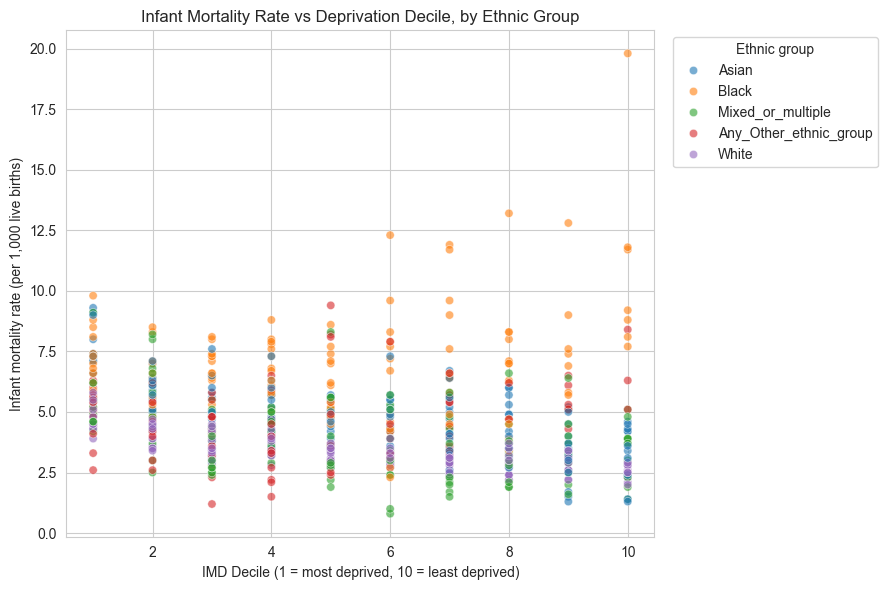

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="imd_decile",
    y="infant_mortality_rate",
    hue="ethnic_group",
    alpha=0.6,
    ax=ax,
)
ax.set_title("Infant Mortality Rate vs Deprivation Decile, by Ethnic Group")
ax.set_xlabel("IMD Decile (1 = most deprived, 10 = least deprived)")
ax.set_ylabel("Infant mortality rate (per 1,000 live births)")
ax.legend(title="Ethnic group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("outputs/figures/deprivation_vs_mortality_scatter.png", dpi=150)
plt.show()

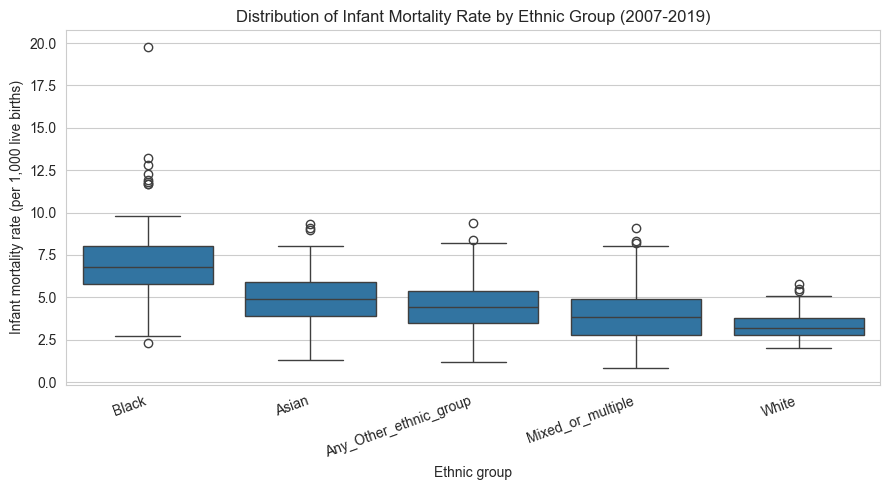

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

order = df.groupby("ethnic_group")["infant_mortality_rate"].median().sort_values(ascending=False).index

sns.boxplot(data=df, x="ethnic_group", y="infant_mortality_rate", order=order, ax=ax)
ax.set_title("Distribution of Infant Mortality Rate by Ethnic Group (2007-2019)")
ax.set_xlabel("Ethnic group")
ax.set_ylabel("Infant mortality rate (per 1,000 live births)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("outputs/figures/mortality_by_ethnicity_boxplot.png", dpi=150)
plt.show()

                       imd_decile  infant_mortality_rate  infant_deaths
imd_decile               1.000000              -0.210080      -0.332129
infant_mortality_rate   -0.210080               1.000000      -0.122908
infant_deaths           -0.332129              -0.122908       1.000000


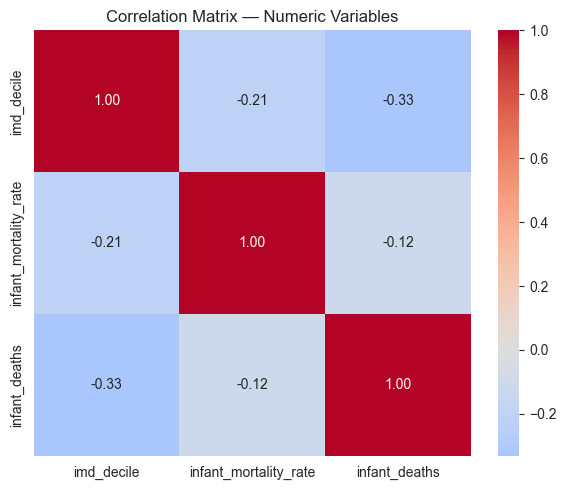

In [18]:
numeric_cols = ["imd_decile", "infant_mortality_rate", "infant_deaths"]
corr = df[numeric_cols].corr()
print(corr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Variables")
plt.tight_layout()
plt.savefig("outputs/figures/correlation_matrix.png", dpi=150)
plt.show()

In [20]:
clean = df.dropna(subset=["imd_decile", "infant_mortality_rate"])
print("Rows before:", len(df), "| Rows after dropping NaN rates:", len(clean))

rho, p_value = spearmanr(clean["imd_decile"], clean["infant_mortality_rate"])
print(f"Spearman rho = {rho:.3f}")
print(f"p-value = {p_value:.2e}")

Rows before: 650 | Rows after dropping NaN rates: 598
Spearman rho = -0.324
p-value = 4.78e-16


In [21]:
clean = clean.copy()
clean["ethnic_group_code"] = clean["ethnic_group"].astype("category").cat.codes

mapping = clean[["ethnic_group", "ethnic_group_code"]].drop_duplicates().sort_values("ethnic_group_code")
print(mapping)

print(clean.shape)
clean.head()

             ethnic_group  ethnic_group_code
3  Any_Other_ethnic_group                  0
0                   Asian                  1
1                   Black                  2
2       Mixed_or_multiple                  3
4                   White                  4
(598, 7)


,year,imd_decile,ethnic_group,infant_deaths,infant_mortality_rate,rate_unreliable_flag,ethnic_group_code
0,2019,1,Asian,110,8.0,False,1
1,2019,1,Black,43,6.6,False,2
2,2019,1,Mixed_or_multiple,33,6.2,False,3
3,2019,1,Any_Other_ethnic_group,18,6.0,True,0
4,2019,1,White,199,3.9,False,4


In [25]:
pip install pgmpy networkx --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [28]:
pip install "pgmpy==0.1.24" --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [29]:

import warnings
warnings.filterwarnings("ignore")

from pgmpy.estimators import PC
import networkx as nx

variables = ["imd_decile", "ethnic_group_code", "infant_mortality_rate"]
pc_data = clean[variables].dropna()

print(pc_data.shape)

pc = PC(data=pc_data)
model = pc.estimate(
    ci_test="pearsonr",
    variant="stable",
    significance_level=0.05,
    show_progress=False,
)

print("Discovered edges:")
for edge in model.edges():
    print(" ", edge)

(598, 3)
Discovered edges:
  ('infant_mortality_rate', 'ethnic_group_code')
  ('imd_decile', 'ethnic_group_code')
  ('imd_decile', 'infant_mortality_rate')


In [30]:
print(type(model))
print(model.edges())

# check if this is a PDAG with some undirected edges
if hasattr(model, "to_dag"):
    try:
        dag = model.to_dag()
        print("\nFully oriented DAG edges:")
        print(dag.edges())
    except Exception as e:
        print("\nCould not fully orient to a DAG:", e)
        print("This means some edges remain undirected given only these 3 variables —")
        print("that's a real and honest finding, not a failure.")

<class 'pgmpy.base.DAG.DAG'>
[('infant_mortality_rate', 'ethnic_group_code'), ('imd_decile', 'ethnic_group_code'), ('imd_decile', 'infant_mortality_rate')]


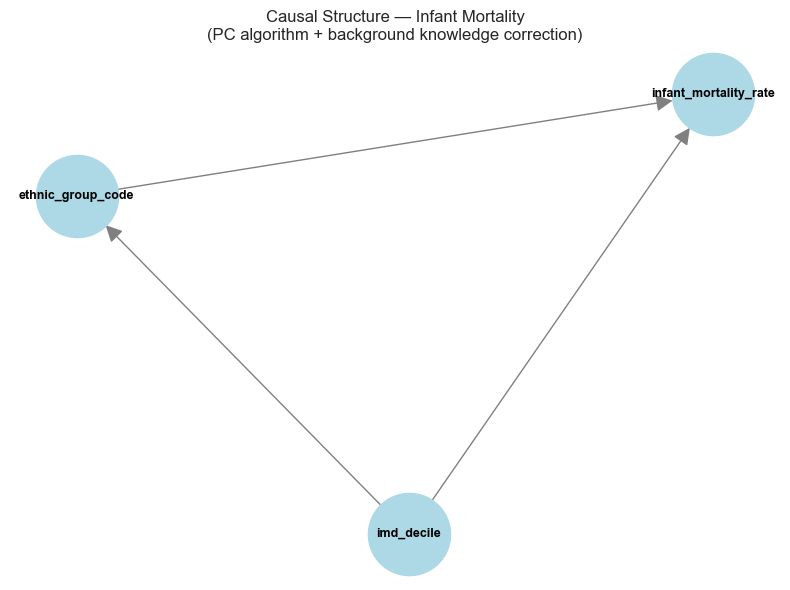

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

corrected_edges = [
    ("ethnic_group_code", "infant_mortality_rate"),
    ("imd_decile", "infant_mortality_rate"),
    ("imd_decile", "ethnic_group_code"),  # deprivation levels differ by ethnic group composition
]

G = nx.DiGraph(corrected_edges)

fig, ax = plt.subplots(figsize=(8, 6))
pos = nx.spring_layout(G, seed=7, k=1.5)
nx.draw(
    G, pos, with_labels=True, node_color="lightblue", node_size=3500,
    font_size=9, font_weight="bold", arrows=True, arrowsize=25,
    edge_color="gray", ax=ax
)
ax.set_title("Causal Structure — Infant Mortality\n(PC algorithm + background knowledge correction)")
plt.tight_layout()
plt.savefig("outputs/figures/causal_dag.png", dpi=150)
plt.show()

In [33]:
pip install dowhy --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [34]:
from dowhy import CausalModel

df_model = clean[["imd_decile", "ethnic_group_code", "infant_mortality_rate"]].dropna()

model = CausalModel(
    data=df_model,
    treatment="imd_decile",
    outcome="infant_mortality_rate",
    common_causes=["ethnic_group_code"],   
)

identified_estimand = model.identify_effect()
print(identified_estimand)

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['imd_decile'] on outcome ['infant_mortality_rate']
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:[]


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                  
─────────────(E[infant_mortality_rate|ethnic_group_code])
d[imd_decile]                                            
Estimand assumption 1, Unconfoundedness: If U→{imd_decile} and U→infant_mortality_rate then P(infant_mortality_rate|imd_decile,ethnic_group_code,U) = P(infant_mortality_rate|imd_decile,ethnic_group_code)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [35]:
causal_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print(causal_estimate)

INFO:dowhy.causal_model:linear_regression
INFO:dowhy.causal_estimator:INFO: Using Linear Regression Estimator
INFO:dowhy.causal_estimator:b: infant_mortality_rate~imd_decile+ethnic_group_code


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                  
─────────────(E[infant_mortality_rate|ethnic_group_code])
d[imd_decile]                                            
Estimand assumption 1, Unconfoundedness: If U→{imd_decile} and U→infant_mortality_rate then P(infant_mortality_rate|imd_decile,ethnic_group_code,U) = P(infant_mortality_rate|imd_decile,ethnic_group_code)

## Realized estimand
b: infant_mortality_rate~imd_decile+ethnic_group_code
Target units: ate

## Estimate
Mean value: -0.13633886973935372



In [48]:
import logging
logging.getLogger("dowhy").setLevel(logging.WARNING)
refutation = model.refute_estimate(
    identified_estimand,
    causal_estimate,
    method_name="random_common_cause",
)

print(refutation)

Refute: Add a random common cause
Estimated effect:-0.13633886973935372
New effect:-0.13635605428452766
p value:0.98



In [38]:
model2 = CausalModel(
    data=df_model,
    treatment="ethnic_group_code",
    outcome="infant_mortality_rate",
    common_causes=["imd_decile"],
)

identified_estimand2 = model2.identify_effect()
print(identified_estimand2)

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['ethnic_group_code'] on outcome ['infant_mortality_rate']
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:[]


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                               
────────────────────(E[infant_mortality_rate|imd_decile])
d[ethnic_group_code]                                     
Estimand assumption 1, Unconfoundedness: If U→{ethnic_group_code} and U→infant_mortality_rate then P(infant_mortality_rate|ethnic_group_code,imd_decile,U) = P(infant_mortality_rate|ethnic_group_code,imd_decile)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



In [39]:
causal_estimate2 = model2.estimate_effect(
    identified_estimand2,
    method_name="backdoor.linear_regression",
)

print(causal_estimate2)

INFO:dowhy.causal_model:linear_regression
INFO:dowhy.causal_estimator:INFO: Using Linear Regression Estimator
INFO:dowhy.causal_estimator:b: infant_mortality_rate~ethnic_group_code+imd_decile


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                               
────────────────────(E[infant_mortality_rate|imd_decile])
d[ethnic_group_code]                                     
Estimand assumption 1, Unconfoundedness: If U→{ethnic_group_code} and U→infant_mortality_rate then P(infant_mortality_rate|ethnic_group_code,imd_decile,U) = P(infant_mortality_rate|ethnic_group_code,imd_decile)

## Realized estimand
b: infant_mortality_rate~ethnic_group_code+imd_decile
Target units: ate

## Estimate
Mean value: -0.37819320502486775



In [40]:
import pandas as pd

# one-hot encode ethnicity, drop White as the reference category
df_dummies = pd.get_dummies(df_model, columns=["ethnic_group_code"], prefix="ethnic")

# find the dummy column names 
# White = code 4, so drop that column manually if get_dummies didn't already
print(df_dummies.columns.tolist())

['imd_decile', 'infant_mortality_rate', 'ethnic_0', 'ethnic_1', 'ethnic_2', 'ethnic_3', 'ethnic_4']


In [41]:
# drop ethnic_4 (White) - it becomes the implicit reference group
df_dummies = df_dummies.drop(columns=["ethnic_4"])

# rename for clarity in output
df_dummies = df_dummies.rename(columns={
    "ethnic_0": "ethnic_any_other",
    "ethnic_1": "ethnic_asian",
    "ethnic_2": "ethnic_black",
    "ethnic_3": "ethnic_mixed",
})

print(df_dummies.columns.tolist())
df_dummies.head()

['imd_decile', 'infant_mortality_rate', 'ethnic_any_other', 'ethnic_asian', 'ethnic_black', 'ethnic_mixed']


,imd_decile,infant_mortality_rate,ethnic_any_other,ethnic_asian,ethnic_black,ethnic_mixed
0,1,8.0,False,True,False,False
1,1,6.6,False,False,True,False
2,1,6.2,False,False,False,True
3,1,6.0,True,False,False,False
4,1,3.9,False,False,False,False


In [47]:
import logging
logging.getLogger("dowhy").setLevel(logging.WARNING)
group_cols = ["ethnic_any_other", "ethnic_asian", "ethnic_black", "ethnic_mixed"]
results = {}

for col in group_cols:
    m = CausalModel(
        data=df_dummies,
        treatment=col,
        outcome="infant_mortality_rate",
        common_causes=["imd_decile"],
    )
    estimand = m.identify_effect()
    estimate = m.estimate_effect(estimand, method_name="backdoor.linear_regression")
    results[col] = estimate.value
    print(f"{col}: {estimate.value:.3f}")

ethnic_any_other: -0.342
ethnic_asian: 0.296
ethnic_black: 2.880
ethnic_mixed: -0.970


In [46]:
import logging
logging.getLogger("dowhy").setLevel(logging.WARNING)
group_names = {
    "ethnic_any_other": 0,
    "ethnic_asian": 1,
    "ethnic_black": 2,
    "ethnic_mixed": 3,
}

results_vs_white = {}

for name, code in group_names.items():
    # keep only this group and White (code 4) for a clean two-group comparison
    subset = clean[clean["ethnic_group_code"].isin([code, 4])].copy()
    subset["is_group"] = (subset["ethnic_group_code"] == code)

    m = CausalModel(
        data=subset,
        treatment="is_group",
        outcome="infant_mortality_rate",
        common_causes=["imd_decile"],
    )
    estimand = m.identify_effect()
    estimate = m.estimate_effect(estimand, method_name="backdoor.linear_regression")
    results_vs_white[name] = estimate.value
    print(f"{name} vs White: {estimate.value:.3f}")

ethnic_any_other vs White: 1.131
ethnic_asian vs White: 1.592
ethnic_black vs White: 3.728
ethnic_mixed vs White: 0.596


In [45]:
import logging
logging.getLogger("dowhy").setLevel(logging.WARNING)
subset_black = clean[clean["ethnic_group_code"].isin([2, 4])].copy()
subset_black["is_black"] = (subset_black["ethnic_group_code"] == 2)

m_black = CausalModel(
    data=subset_black,
    treatment="is_black",
    outcome="infant_mortality_rate",
    common_causes=["imd_decile"],
)
estimand_black = m_black.identify_effect()
estimate_black = m_black.estimate_effect(estimand_black, method_name="backdoor.linear_regression")

refutation_black = m_black.refute_estimate(
    estimand_black,
    estimate_black,
    method_name="random_common_cause",
)
print(refutation_black)

Refute: Add a random common cause
Estimated effect:3.7284625262887405
New effect:3.727289456130029
p value:1.0

